# Land Cover Change Detection: Fix 2022/2023 Composites

The Jul–Aug composites for 2022 and 2023 have ~17% NaN pixels in the eastern AOI because too few cloud-free scenes fell within that window (2022 had only 12 scenes, with the effective start date of July 23). This notebook widens the temporal window to June–August for those two years and rebuilds the composites.

Everything else — cloud masking, baseline harmonization, NDVI formula, output format — is unchanged from notebook 02.

**Inputs:** `data/composites/ndvi_2022.tif`, `ndvi_2023.tif` (existing); all 8 composites for the final grid  
**Outputs:** `ndvi_2022.tif` and `ndvi_2023.tif` overwritten with Jun–Aug data; originals backed up as `ndvi_2022_jul_aug.tif` and `ndvi_2023_jul_aug.tif`  
**Expected runtime:** 30–60 min (two years)

In [1]:
import gc
import shutil
import time
import warnings
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import planetary_computer
import pystac_client
import rasterio
import rasterio.transform
import stackstac
import xarray as xr
from dask.distributed import Client, LocalCluster

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

DATA_DIR = Path("data")
COMPOSITES_DIR = DATA_DIR / "composites"

FIX_YEARS = [2022, 2023]
ALL_YEARS = list(range(2018, 2026))

## Dask Cluster

In [2]:
cluster = LocalCluster(n_workers=2, threads_per_worker=2, memory_limit="4GB")
client = Client(cluster)
print(f"Dask dashboard: {client.dashboard_link}")
print(f"Workers:        {len(client.scheduler_info()['workers'])}")

Dask dashboard: http://127.0.0.1:8787/status
Workers:        2


## AOI and STAC Connection

In [3]:
aoi_5070 = gpd.read_file(DATA_DIR / "gsmnp_aoi.gpkg")
aoi_4326 = gpd.read_file(DATA_DIR / "gsmnp_aoi_4326.geojson")
aoi_geom = aoi_4326.geometry.iloc[0]
bbox_4326 = aoi_4326.total_bounds.tolist()

catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)
print(f"AOI area:  {aoi_5070.area.sum() / 1e6:.0f} km²")
print(f"STAC bbox: {[round(v, 4) for v in bbox_4326]}")

AOI area:  5103 km²
STAC bbox: [-84.1252, 35.3397, -82.8867, 35.9307]


## Retry Helpers

In [4]:
PC_STAC_URL = "https://planetarycomputer.microsoft.com/api/stac/v1"

GDAL_ENV = {
    "GDAL_HTTP_MAX_RETRY": "5",
    "GDAL_HTTP_RETRY_DELAY": "3",
    "GDAL_HTTP_TIMEOUT": "60",
}


def stac_search_with_retry(catalog, retries=5, backoff=10, **search_kwargs):
    for attempt in range(retries):
        try:
            search = catalog.search(**search_kwargs)
            items = list(search.items())
            return items, catalog
        except Exception as e:
            if attempt == retries - 1:
                raise
            wait = backoff * (attempt + 1)
            print(f"       STAC search failed (attempt {attempt + 1}/{retries}): {type(e).__name__}: {e}")
            print(f"       Reconnecting in {wait}s...")
            time.sleep(wait)
            catalog = pystac_client.Client.open(
                PC_STAC_URL,
                modifier=planetary_computer.sign_inplace,
            )


def dask_compute_with_retry(client, *lazy_arrays, retries=3, backoff=30):
    for attempt in range(retries):
        try:
            futures = client.compute(list(lazy_arrays))
            results = client.gather(futures)
            return tuple(results)
        except Exception as e:
            if attempt == retries - 1:
                raise
            wait = backoff * (attempt + 1)
            print(f"       Compute failed (attempt {attempt + 1}/{retries}): {type(e).__name__}")
            print(f"       Retrying in {wait}s...")
            time.sleep(wait)

## Back Up Existing Composites

Before overwriting, copy the Jul–Aug versions to `ndvi_2022_jul_aug.tif` and `ndvi_2023_jul_aug.tif`. This preserves them for the before/after comparison below and as a fallback.

In [5]:
VALID_SCL = {4, 5, 6}

for year in FIX_YEARS:
    src_path = COMPOSITES_DIR / f"ndvi_{year}.tif"
    bak_path = COMPOSITES_DIR / f"ndvi_{year}_jul_aug.tif"
    if src_path.exists() and not bak_path.exists():
        shutil.copy2(src_path, bak_path)
        print(f"Backed up {src_path.name} → {bak_path.name}")
    elif bak_path.exists():
        print(f"Backup already exists: {bak_path.name}")
    else:
        print(f"Source not found: {src_path.name}")

Backed up ndvi_2022.tif → ndvi_2022_jul_aug.tif
Backed up ndvi_2023.tif → ndvi_2023_jul_aug.tif


## Recomposite 2022 and 2023 with June–August Window

The only change from notebook 02: the datetime parameter is `{year}-06-01/{year}-08-31` instead of `{year}-07-01/{year}-08-31`. Adding June gives the composite ~30 additional days of potential observations, which is enough to fill the eastern coverage gap in both years.

The loop does not skip existing files — it overwrites them.

In [6]:
for year in FIX_YEARS:
    t0 = time.time()
    out_path = COMPOSITES_DIR / f"ndvi_{year}.tif"

    # --- 1. STAC search with wider Jun–Aug window ---
    items, catalog = stac_search_with_retry(
        catalog,
        collections=["sentinel-2-l2a"],
        bbox=bbox_4326,
        datetime=f"{year}-06-01/{year}-08-31",
        query={"eo:cloud_cover": {"lt": 20}},
    )
    print(f"\n{year}: {len(items)} scenes found (Jun–Aug, cloud < 20%)")

    # --- 2. Stack (lazy) ---
    stack = stackstac.stack(
        items,
        assets=["B04", "B08", "SCL"],
        epsg=5070,
        resolution=10,
        chunksize=1024,
        bounds_latlon=aoi_geom.bounds,
        gdal_env=stackstac.DEFAULT_GDAL_ENV.updated(always=GDAL_ENV),
        errors_as_nodata=(Exception(".*"),),
    )

    # --- 3. Baseline harmonization ---
    bl_coord = stack.coords["s2:processing_baseline"]
    if bl_coord.ndim == 0:
        needs_offset = np.full(stack.sizes["time"], str(bl_coord.values) >= "04.00")
    else:
        needs_offset = np.array([str(b) >= "04.00" for b in bl_coord.values])

    b04 = stack.sel(band="B04")
    b08 = stack.sel(band="B08")
    scl = stack.sel(band="SCL")

    offset_da = xr.DataArray(
        1000.0 * needs_offset,
        dims=["time"],
        coords={"time": b04.time},
    )
    b04 = (b04 - offset_da).clip(min=0)
    b08 = (b08 - offset_da).clip(min=0)

    print(f"       harmonized {int(needs_offset.sum())}/{len(items)} scenes (baseline >= 04.00)")

    # --- 4. SCL cloud mask ---
    valid_mask = sum(scl == v for v in VALID_SCL).astype(bool)
    b04 = b04.where(valid_mask)
    b08 = b08.where(valid_mask)

    # --- 5. NDVI ---
    ndvi = (b08 - b04) / (b08 + b04)

    # --- 6. Median + valid count (lazy) ---
    ndvi_median = ndvi.median(dim="time")
    valid_count = ndvi.notnull().sum(dim="time").astype("float32")

    # --- 7. Compute ---
    print(f"       computing...")
    ndvi_result, count_result = dask_compute_with_retry(client, ndvi_median, valid_count)
    ndvi_arr = ndvi_result.values.astype("float32")
    count_arr = count_result.values.astype("float32")
    del ndvi_result, count_result

    res = 10
    x0 = float(ndvi_median.x[0]) - res / 2
    y0 = float(ndvi_median.y[0]) + res / 2
    transform = rasterio.transform.from_origin(x0, y0, res, res)

    # --- 8. Write GeoTIFF (overwrites existing file) ---
    meta = {
        "driver": "GTiff",
        "dtype": "float32",
        "count": 2,
        "crs": "EPSG:5070",
        "transform": transform,
        "width": ndvi_arr.shape[1],
        "height": ndvi_arr.shape[0],
        "nodata": float("nan"),
        "compress": "lzw",
    }
    with rasterio.open(out_path, "w", **meta) as dst:
        dst.write(ndvi_arr, 1)
        dst.update_tags(1, description="Median NDVI (Jun-Aug)")
        dst.write(count_arr, 2)
        dst.update_tags(2, description="Valid observation count")

    elapsed = time.time() - t0
    mean_ndvi = float(np.nanmean(ndvi_arr))
    pct_low = float(np.mean(count_arr[~np.isnan(ndvi_arr)] < 3) * 100)
    size_mb = out_path.stat().st_size / 1e6
    print(f"       done in {elapsed/60:.1f} min | mean NDVI {mean_ndvi:.3f} | "
          f"<3 obs: {pct_low:.1f}% | {size_mb:.0f} MB → {out_path.name}")

    # --- 9. Release memory ---
    del stack, b04, b08, scl, ndvi, ndvi_median, valid_count, ndvi_arr, count_arr
    client.run(gc.collect)
    gc.collect()

print("\nDone.")


2022: 30 scenes found (Jun–Aug, cloud < 20%)
       harmonized 30/30 scenes (baseline >= 04.00)
       computing...


/home/jovyan/.local/lib/python3.10/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
2026-04-07 22:23:51,384 - distributed.worker.memory - WARNING - Worker is at 80% memory usage. Pausing worker.  Process memory: 2.99 GiB -- Worker memory limit: 3.73 GiB
2026-04-07 22:23:51,390 - distributed.worker.memory - WARNING - Worker is at 78% memory usage. Resuming worker. Process memory: 2.92 GiB -- Worker memory limit: 3.73 GiB
/home/jovyan/.local/lib/python3.10/site-packages/dask/_task_spec.py:767: RuntimeWarning: All-NaN slice encountered
  return self.func(*new_argspec, **kwargs)
2026-04-07 22:23:54,848 - distributed.worker.memory - WARNING - Worker is at 81% memory usage. Pausing worker.  Process memory: 3.02 GiB -- Worker memory limit: 3.73 GiB
2026-04-07 22:23:56,098 - distributed.worker.memory - WARNING - Worker is at 71% memory usage. Resuming worker. Process memory: 2.68 GiB -- Worker memory limit: 3.73 GiB
2026

       done in 17.2 min | mean NDVI 0.820 | <3 obs: 15.0% | 447 MB → ndvi_2022.tif

2023: 42 scenes found (Jun–Aug, cloud < 20%)
       harmonized 42/42 scenes (baseline >= 04.00)
       computing...


/home/jovyan/.local/lib/python3.10/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
2026-04-07 22:46:55,805 - distributed.worker.memory - WARNING - Worker is at 81% memory usage. Pausing worker.  Process memory: 3.02 GiB -- Worker memory limit: 3.73 GiB
2026-04-07 22:46:56,586 - distributed.worker.memory - WARNING - Worker is at 76% memory usage. Resuming worker. Process memory: 2.84 GiB -- Worker memory limit: 3.73 GiB
2026-04-07 22:47:22,170 - distributed.worker.memory - WARNING - Worker is at 82% memory usage. Pausing worker.  Process memory: 3.09 GiB -- Worker memory limit: 3.73 GiB
2026-04-07 22:47:22,487 - distributed.worker.memory - WARNING - Worker is at 79% memory usage. Resuming worker. Process memory: 2.97 GiB -- Worker memory limit: 3.73 GiB
2026-04-07 22:47:41,814 - distributed.worker.memory - WARNING - Worker is at 85% memory usage. Pausing worker.  Process memory: 3.19 GiB -- Worker memory limit: 3

       done in 24.2 min | mean NDVI 0.808 | <3 obs: 12.9% | 447 MB → ndvi_2023.tif

Done.


## Before/After Comparison

Two rows, two columns. Top row is the original Jul–Aug composites; bottom row is the new Jun–Aug composites. The eastern coverage gap (grey) should be absent or substantially reduced in the bottom row.

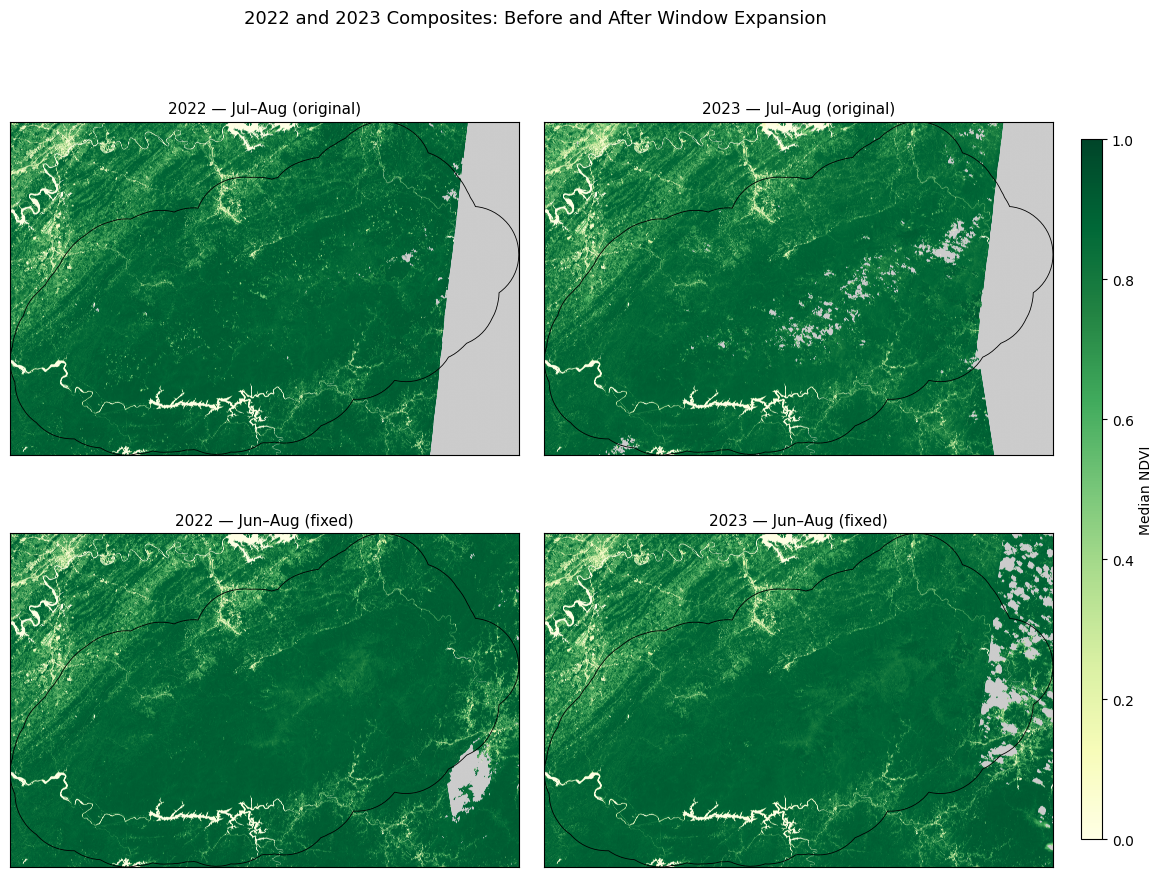

In [7]:
cmap = plt.cm.YlGn.copy()
cmap.set_bad(color="#cccccc")

xmin, ymin, xmax, ymax = aoi_5070.total_bounds

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
row_labels = ["Jul–Aug (original)", "Jun–Aug (fixed)"]

for col, year in enumerate(FIX_YEARS):
    paths = [
        COMPOSITES_DIR / f"ndvi_{year}_jul_aug.tif",  # original
        COMPOSITES_DIR / f"ndvi_{year}.tif",           # fixed
    ]
    for row, path in enumerate(paths):
        ax = axes[row][col]
        with rasterio.open(path) as src:
            ndvi = src.read(1)
            extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]

        ax.set_facecolor("#cccccc")
        im = ax.imshow(ndvi, cmap=cmap, vmin=0, vmax=1, extent=extent, origin="upper")
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        aoi_5070.boundary.plot(ax=ax, color="black", linewidth=0.6)
        ax.set_title(f"{year} — {row_labels[row]}", fontsize=11)
        ax.set_xticks([])
        ax.set_yticks([])

fig.subplots_adjust(right=0.87, wspace=0.05, hspace=0.15)
cbar_ax = fig.add_axes([0.89, 0.15, 0.015, 0.7])
fig.colorbar(im, cax=cbar_ax, label="Median NDVI")
plt.suptitle("2022 and 2023 Composites: Before and After Window Expansion", fontsize=13)
plt.show()

## Per-Year Statistics — All Eight Years

NaN% for 2022 and 2023 should now be in line with the other years (< 5%). The `<3 obs %` may increase slightly because June scenes are fewer than peak summer, but the overall coverage improvement should be large.

In [8]:
rows = []
for year in ALL_YEARS:
    path = COMPOSITES_DIR / f"ndvi_{year}.tif"
    with rasterio.open(path) as src:
        ndvi = src.read(1).astype("float32")
        count = src.read(2).astype("float32")

    valid = ~np.isnan(ndvi)
    rows.append({
        "year": year,
        "window": "Jun–Aug" if year in FIX_YEARS else "Jul–Aug",
        "min": f"{np.nanmin(ndvi):.3f}",
        "max": f"{np.nanmax(ndvi):.3f}",
        "mean": f"{np.nanmean(ndvi):.3f}",
        "std": f"{np.nanstd(ndvi):.3f}",
        "<3 obs %": f"{np.mean(count[valid] < 3) * 100:.1f}%",
        "NaN %": f"{np.mean(~valid) * 100:.1f}%",
        "size MB": f"{path.stat().st_size / 1e6:.0f}",
    })

stats = pd.DataFrame(rows).set_index("year")
print(stats.to_string())

       window     min    max   mean    std <3 obs % NaN % size MB
year                                                             
2018  Jul–Aug  -0.999  0.989  0.808  0.162     3.9%  0.3%     451
2019  Jul–Aug  -0.999  0.999  0.811  0.170    15.3%  0.3%     455
2020  Jul–Aug  -0.987  1.000  0.789  0.183    17.3%  1.6%     457
2021  Jul–Aug  -0.999  1.000  0.790  0.167    15.0%  0.5%     454
2022  Jun–Aug  -1.000  1.000  0.820  0.184    15.0%  1.3%     447
2023  Jun–Aug  -1.000  1.000  0.808  0.177    12.9%  3.1%     447
2024  Jul–Aug  -1.000  0.998  0.800  0.179    10.9%  0.5%     446
2025  Jul–Aug  -1.000  1.000  0.803  0.184    18.8%  2.0%     444


## Full Annual Grid — All Eight Years

Same quick-look grid as notebook 02, now reflecting the fixed composites. All eight panels should show complete AOI coverage with no grey interior patches.

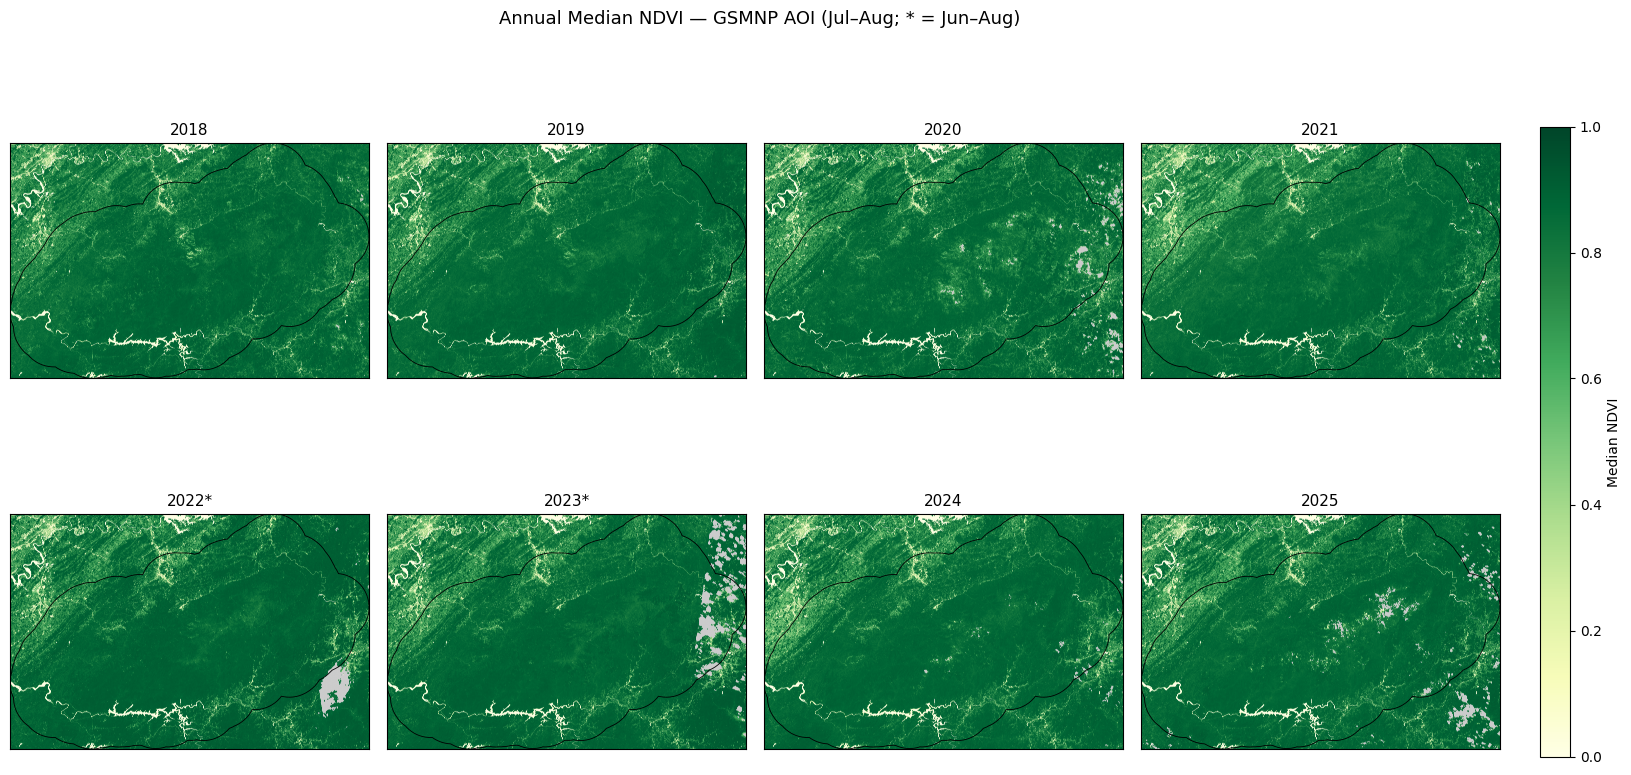

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for ax, year in zip(axes, ALL_YEARS):
    path = COMPOSITES_DIR / f"ndvi_{year}.tif"
    with rasterio.open(path) as src:
        ndvi = src.read(1)
        extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]

    ax.set_facecolor("#cccccc")
    im = ax.imshow(ndvi, cmap=cmap, vmin=0, vmax=1, extent=extent, origin="upper")
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    aoi_5070.boundary.plot(ax=ax, color="black", linewidth=0.6)
    label = f"{year}*" if year in FIX_YEARS else str(year)
    ax.set_title(label, fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])

fig.subplots_adjust(right=0.87, wspace=0.05, hspace=0.15)
cbar_ax = fig.add_axes([0.89, 0.15, 0.015, 0.7])
fig.colorbar(im, cax=cbar_ax, label="Median NDVI")
plt.suptitle("Annual Median NDVI — GSMNP AOI (Jul–Aug; * = Jun–Aug)", fontsize=13)
plt.show()

## Cleanup

In [10]:
client.close()
cluster.close()
print("Dask cluster shut down.")

Dask cluster shut down.


## Before Proceeding to Notebook 03

Verify:
- NaN% for 2022 and 2023 is below 5% in the stats table
- The before/after grid shows the eastern grey region filled in
- Mean NDVI for 2022/2023 remains in the 0.78–0.82 range
- No new coverage gaps introduced in other years

If both years look clean, proceed to `03_lccd_change_detection.ipynb`.